In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset and understanding its structure

df = pd.read_csv("monthly_milk_production.csv")

print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

df.head()

Shape: (168, 2)

Column Names:
Index(['Date', 'Production'], dtype='object')


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
# Checking dataset information and missing values

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None

Missing Values:
Date          0
Production    0
dtype: int64


In [5]:
# Converting Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

df.head()

Date          datetime64[ns]
Production             int64
dtype: object


,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


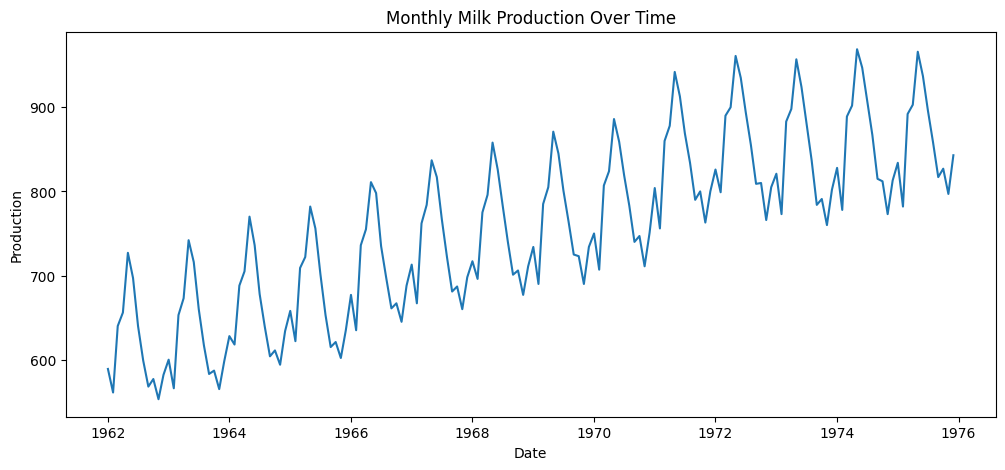

In [6]:
# Visualizing milk production trend over time

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Production'])

plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')

plt.show()

In [7]:
# Basic statistical summary

df['Production'].describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


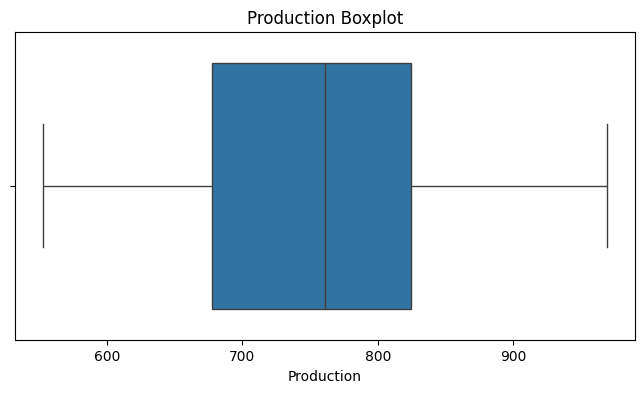

In [8]:
# Checking outliers using boxplot

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Production'])

plt.title('Production Boxplot')
plt.show()

In [9]:
# Scaling data for deep learning models

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

print(scaled_data[:5])
print("\nShape:", scaled_data.shape)

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]

Shape: (168, 1)


In [10]:
# Creating input-output sequences

def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

window_size = 12

X, y = create_sequences(scaled_data, window_size)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (156, 12, 1)
y Shape: (156, 1)


In [11]:
# Splitting data into training and testing sets

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (124, 12, 1)
X_test : (32, 12, 1)
y_train: (124, 1)
y_test : (32, 1)


In [12]:
# Importing deep learning libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [13]:
# Building and training the Basic RNN model

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.1871 - val_loss: 0.0316
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0569 - val_loss: 0.0294
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0234 - val_loss: 0.0681
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0154 - val_loss: 0.0094
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0108 - val_loss: 0.0087
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0078 - val_loss: 0.0161
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0062 - val_loss: 0.0080
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0049 - val_loss: 0.0060
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - val_loss: 0.0069
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0036 - val_loss: 0.0047
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0030 - val_loss: 0.0045
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0028 - val_loss: 0.0037
Epoch 13/20


In [14]:
# Building and training the LSTM model

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.2325 - val_loss: 0.2411
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0577 - val_loss: 0.0266
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0376 - val_loss: 0.0335
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0304 - val_loss: 0.0358
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0283 - val_loss: 0.0389
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0265 - val_loss: 0.0291
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0260 - val_loss: 0.0260
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0259 - val_loss: 0.0274
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0294
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0247 - val_loss: 0.0263
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0247 - val_loss: 0.0247
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0240 - val_loss: 0.0260
E

In [15]:
# Checking final LSTM losses

print("Final Training Loss :", history_lstm.history['loss'][-1])
print("Final Validation Loss :", history_lstm.history['val_loss'][-1])

Final Training Loss : 0.02089330181479454
Final Validation Loss : 0.021060308441519737


In [16]:
# Building and training the GRU model

gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.1616 - val_loss: 0.1686
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0409 - val_loss: 0.0252
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0349 - val_loss: 0.0246
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0294 - val_loss: 0.0309
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0247 - val_loss: 0.0396
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0243 - val_loss: 0.0326
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0231 - val_loss: 0.0244
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0223 - val_loss: 0.0246
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0219 - val_loss: 0.0261
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0209 - val_loss: 0.0230
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0207 - val_loss: 0.0216
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0199 - val_loss: 0.0236
E

In [17]:
# Checking final GRU losses

print("Final Training Loss :", history_gru.history['loss'][-1])
print("Final Validation Loss :", history_gru.history['val_loss'][-1])

Final Training Loss : 0.01663103885948658
Final Validation Loss : 0.017674529924988747


In [18]:
# Generating predictions from all models

rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


In [20]:
# Converting scaled values back to original production values

y_test_actual = scaler.inverse_transform(y_test)

rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

In [22]:
# Calculating forecasting metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    return rmse, mae, mape

rnn_rmse, rnn_mae, rnn_mape = evaluate_model(y_test_actual, rnn_pred_actual)

lstm_rmse, lstm_mae, lstm_mape = evaluate_model(y_test_actual, lstm_pred_actual)

gru_rmse, gru_mae, gru_mape = evaluate_model(y_test_actual, gru_pred_actual)

In [23]:
# Comparing RNN, LSTM, and GRU

results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'MAPE (%)': [rnn_mape, lstm_mape, gru_mape]
})

results

,Model,RMSE,MAE,MAPE (%)
0,RNN,20.807029,17.873631,2.078702
1,LSTM,60.370626,53.142351,6.197629
2,GRU,55.305367,43.660868,4.960986


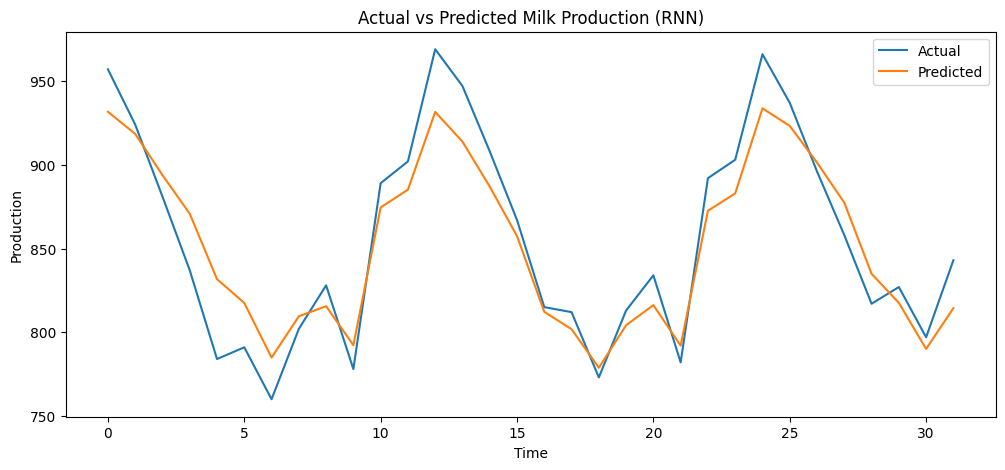

In [24]:
# Actual vs Predicted values for the best model (RNN)

plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label='Actual')
plt.plot(rnn_pred_actual, label='Predicted')

plt.title('Actual vs Predicted Milk Production (RNN)')
plt.xlabel('Time')
plt.ylabel('Production')

plt.legend()

plt.show()

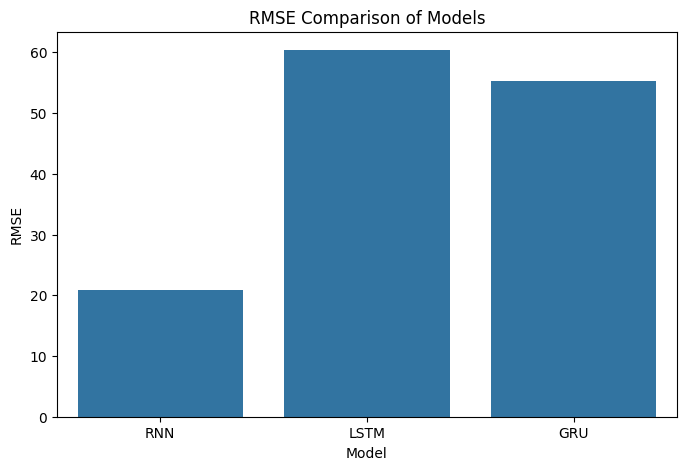

In [25]:
# Visual comparison of model performance

plt.figure(figsize=(8,5))

sns.barplot(data=results, x='Model', y='RMSE')

plt.title('RMSE Comparison of Models')

plt.show()

In [26]:
# Forecasting next 12 months using the best model (RNN)

future_predictions = []

last_sequence = scaled_data[-window_size:]

current_sequence = last_sequence.copy()

for _ in range(12):

    pred = rnn_model.predict(
        current_sequence.reshape(1, window_size, 1),
        verbose=0
    )

    future_predictions.append(pred[0, 0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    ).reshape(window_size, 1)

In [27]:
# Converting forecasts back to original production values

future_predictions = np.array(future_predictions).reshape(-1, 1)

future_predictions_actual = scaler.inverse_transform(
    future_predictions
)

future_predictions_actual.flatten()

array([823.25073, 798.3949 , 874.4906 , 886.2461 , 932.40784, 918.3057 ,
       893.61957, 870.81396, 835.41296, 835.19305, 814.5627 , 841.0603 ],
      dtype=float32)

**Business Insights**

Based on the forecasting results, the RNN model performed better than the LSTM and GRU models.

 The forecasted milk production values show that production is expected to remain stable in the coming months with regular seasonal variations.

These predictions can help the dairy business plan production, manage storage facilities, allocate resources efficiently, and prepare for future demand.


This can reduce wastage and improve overall operational planning.



## Conclusion

In this project, monthly milk production forecasting was performed using RNN, LSTM, and GRU models. The data was analyzed, scaled, and converted into time sequences before training the models.

The performance of the models was evaluated using RMSE, MAE, and MAPE. Among all models, the RNN model achieved the best results with RMSE = 20.81, MAE = 17.87, and MAPE = 2.08%.

The trained RNN model was used to forecast milk production for the next 12 months. The forecast indicates stable production with seasonal changes. Therefore, the RNN model can be effectively used for future milk production planning and decision-making.
